# Precision table

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [26]:

MODELS = [
    'gpt-3.5-turbo', 'gpt-4-turbo', 'gpt-4o-mini', 'gpt-4o',
    'claude_3_opus', 'claude_3.5_sonnet',
    'gemini-1.5-flash', 'gemini-1.5-pro',
    'qwen-coder-plus',
    'deepseek-chat'
]

pGa_CONST = {
    'gpt-4o': 0.93478,
    'gpt-4-turbo': 0.87144,
    'gpt-3.5-turbo': 0.69825,
    'claude_3_opus': 0.95402,
    'gemini-1.5-pro': 0.92846,
    'deepseek-chat': 0.92841,
    'qwen-coder-plus': 0.93117
}

pG_ensemble = {
    'gpt-3.5-turbo': 0.655,
    'gpt-4-turbo': 0.918,
    'gpt-4o-mini': 0.952,
    'gpt-4o': 0.925,
    'claude_3_opus': 0.971,
    'claude_3.5_sonnet': 0.971,
    'gemini-1.5-flash': 0.975,
    'gemini-1.5-pro': 0.975,
    'qwen-coder-plus': 0.954,
    'deepseek-chat': 0.955
}

pricing = [1.5, 30, 0.6, 10,
           75, 15,
           0.3, 5,
           0.96, 2.19]

In [31]:
df = pd.DataFrame(
    {'model': MODELS, 'pG': pG_ensemble.values(), 'pricing': pricing}
)

df

,model,pG,pricing
0,gpt-3.5-turbo,0.655,1.50
1,gpt-4-turbo,0.918,30.00
2,gpt-4o-mini,0.952,0.60
3,gpt-4o,0.925,10.00
4,claude_3_opus,0.971,75.00
5,claude_3.5_sonnet,0.971,15.00
6,gemini-1.5-flash,0.975,0.30
7,gemini-1.5-pro,0.975,5.00
8,qwen-coder-plus,0.954,0.96
9,deepseek-chat,0.955,2.19


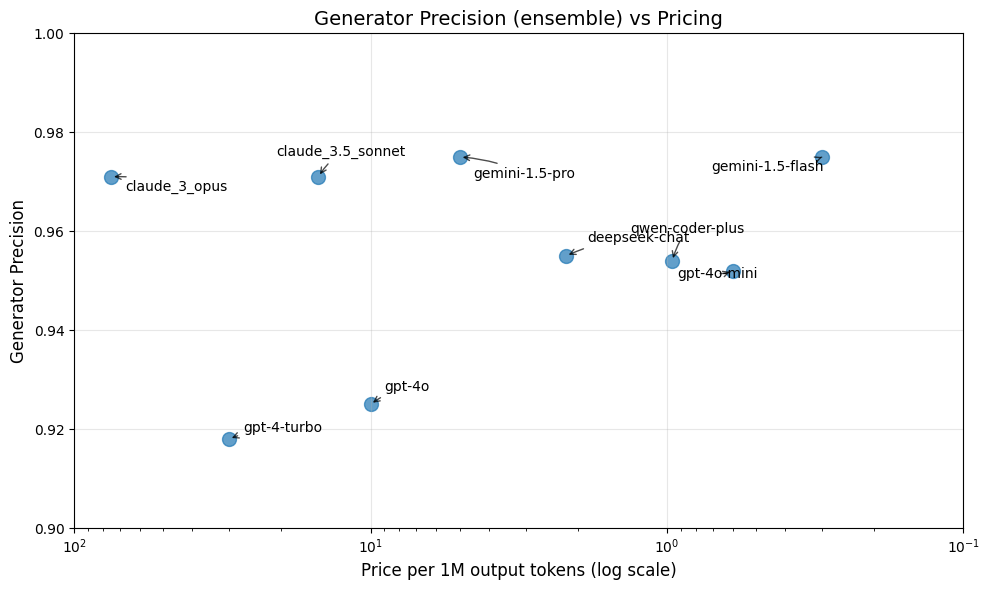

In [38]:
# Create the scatter plot with log scale on x-axis
plt.figure(figsize=(10, 6))
plt.scatter(df['pricing'], df['pG'], alpha=0.7, s=100)
# Add labels for each point with offset based on model positions
offsets = {
    'gpt-3.5-turbo': (-20, -15),
    'gpt-4-turbo': (10, 5),
    'gpt-4o-mini': (-40, -5),
    'gpt-4o': (10, 10),
    'claude_3_opus': (10, -10),
    'claude_3.5_sonnet': (-30, 15),
    'gemini-1.5-flash': (-80, -10),
    'gemini-1.5-pro': (10, -15),
    'qwen-coder-plus': (-30, 20),
    'deepseek-chat': (15, 10)
}

for i, model in enumerate(df['model']):
    plt.annotate(model, 
                (df['pricing'].iloc[i], df['pG'].iloc[i]),
                xytext=offsets[model], 
                textcoords='offset points',
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.1', alpha=0.7))

# Add title and labels
plt.title('Generator Precision (ensemble) vs Pricing', fontsize=14)
plt.xlabel('Price per 1M output tokens (log scale)', fontsize=12)
plt.ylabel('Generator Precision', fontsize=12)
plt.grid(True, alpha=0.3)

# Set x-axis to log scale
plt.xscale('log')

# Set x-axis limits from 10^0 to 10^2
plt.xlim(100, 0.1)  # Flipped the order to go from high to low
plt.ylim(0.9, 1.0)

plt.tight_layout()
plt.show()


## Loss plots

In [75]:
def plot_loss(k=2, method='BFGS', lossGV='crossEntropy', lossOthers='RMSE', weights=[], ylim=1e-3):
    weightGV, weightG, weightVV, weightVIV = weights
    weightsStr = '-'.join(map(str, weights))
    df = pd.read_csv(f'../output/logs/loss iteration/{method}_{lossGV}_{lossOthers}_{weightsStr}.csv')
    
    plt.figure(figsize=(12, 6))

    # Get the last values for annotations
    last_iter = df['iter'].iloc[-1]
    last_train_loss_GV = df['train_loss_GV'].iloc[-1]
    last_train_loss_g = df['train_loss_g'].iloc[-1]
    last_train_loss_vv = df['train_loss_vv'].iloc[-1]
    last_train_loss_viv = df['train_loss_viv'].iloc[-1]
    last_test_loss_g = df['test_loss_g'].iloc[-1]

    # Plot all training losses with solid lines
    plt.plot(df['iter'], df['train_loss_GV'], color='green', linewidth=2, label=f'GV ({weightGV}x)')
    plt.plot(df['iter'], df['train_loss_vv'], color='purple', linewidth=2, label=f'V+ ({weightVV}x)')
    plt.plot(df['iter'], df['train_loss_viv'], color='orange', linewidth=2, label=f'V- ({weightVIV}x)')
    plt.plot(df['iter'], df['test_loss_g'], color='red', linewidth=2, linestyle='--', label='G Test')
    plt.plot(df['iter'], df['train_loss_g'], color='blue', linewidth=2, label=f'G Train ({weightG}x)')

    # Add annotations for the final values
    plt.annotate(f'{last_train_loss_GV:.6f}', xy=(last_iter, last_train_loss_GV), 
                 xytext=(last_iter + 50, last_train_loss_GV), color='green')
    
    plt.annotate(f'{last_train_loss_vv:.6f}', xy=(last_iter, last_train_loss_vv), 
                 xytext=(last_iter + 50, last_train_loss_vv), color='purple')
    
    plt.annotate(f'{last_train_loss_viv:.6f}', xy=(last_iter, last_train_loss_viv), 
                 xytext=(last_iter + 50, last_train_loss_viv), color='orange')
    
    plt.annotate(f'{last_test_loss_g:.6f}', xy=(last_iter, last_test_loss_g), 
                 xytext=(last_iter + 50, last_test_loss_g), color='red')
    
    plt.annotate(f'{last_train_loss_g:.6f}', xy=(last_iter, last_train_loss_g), 
                 xytext=(last_iter + 50, last_train_loss_g), color='blue')

    # Add labels and title
    plt.xlabel('Iterations', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title(f'k={k} method={method} lossGV={lossGV} lossOthers={lossOthers}', fontsize=14)

    # Add grid and legend
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)

    # Use log scale for y-axis as the loss values span several orders of magnitude
    plt.yscale('log')

    # Add some padding to the x-axis to make room for annotations
    plt.xlim(0, last_iter + 350)
    plt.ylim(ylim, 1)

    plt.tight_layout()
    plt.show()

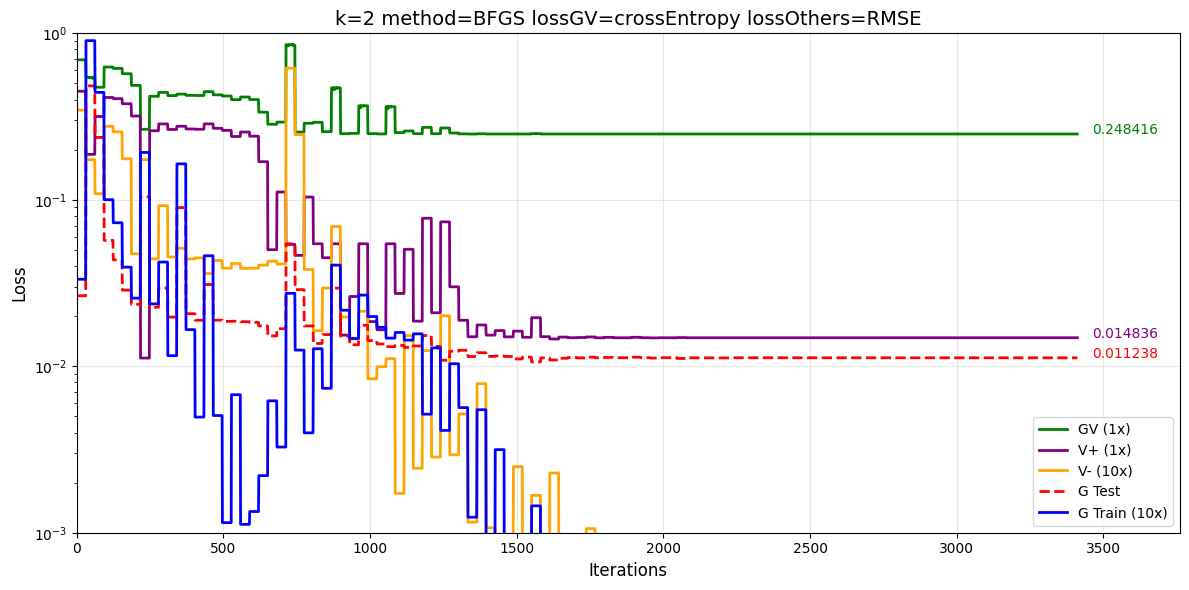

In [67]:
plot_loss(k=2, method='BFGS', lossGV='crossEntropy', lossOthers='RMSE', weights=[1, 10, 1, 10])

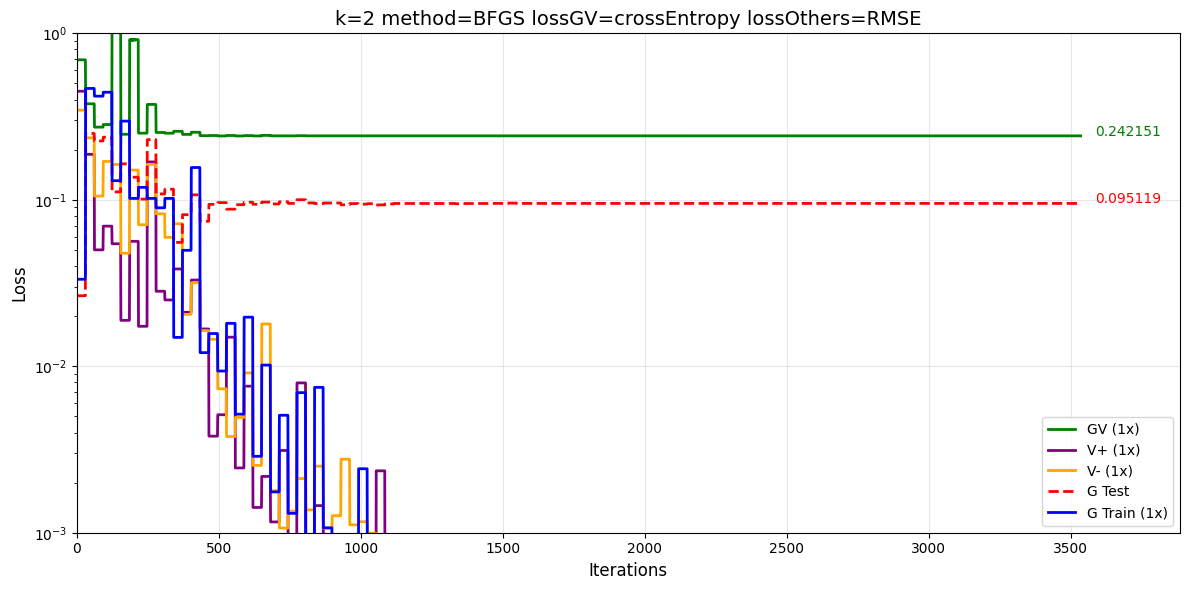

In [68]:
plot_loss(k=2, method='BFGS', lossGV='crossEntropy', lossOthers='RMSE', weights=[1, 1, 1, 1])

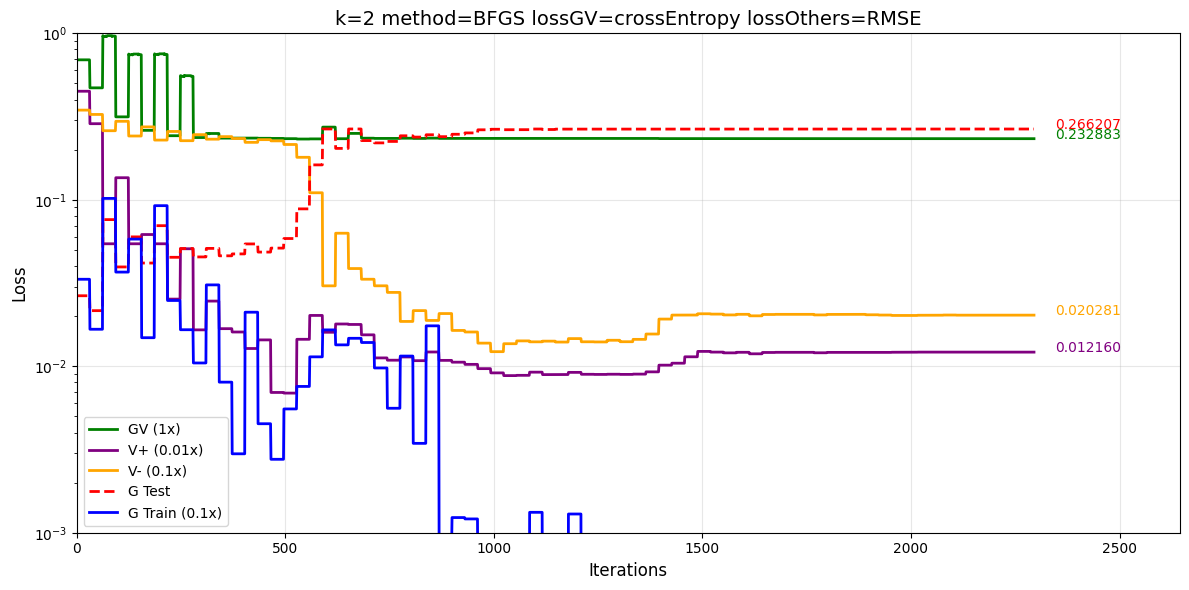

In [69]:

plot_loss(k=2, method='BFGS', lossGV='crossEntropy', lossOthers='RMSE', weights=[1, 0.1, 0.01, 0.1])

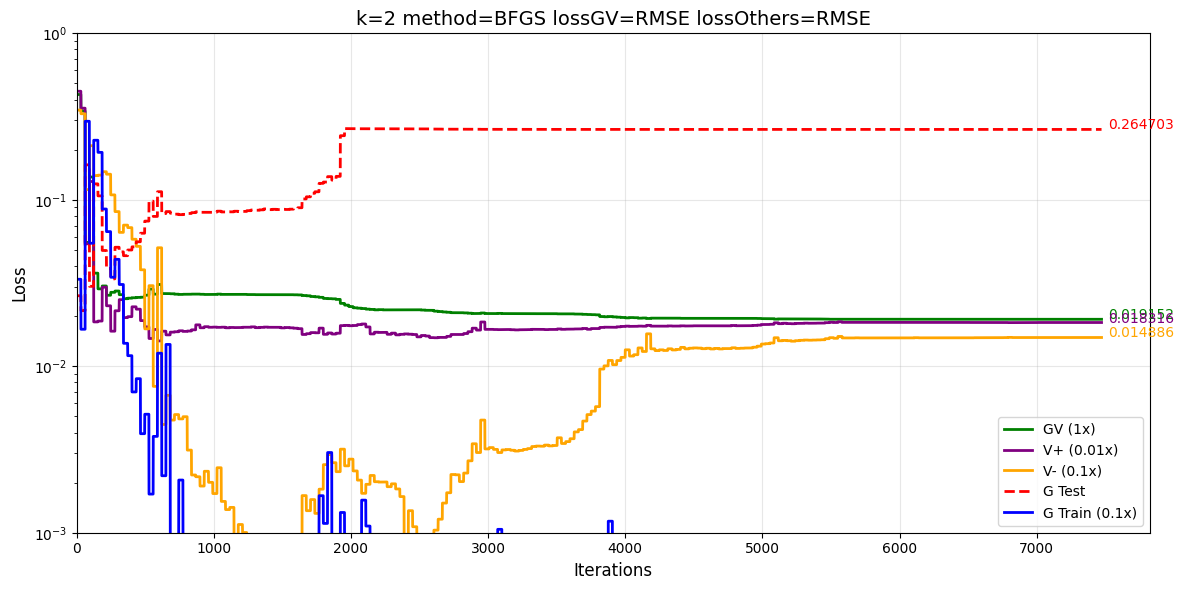

In [70]:

plot_loss(k=2, method='BFGS', lossGV='RMSE', lossOthers='RMSE', weights=[1, 0.1, 0.01, 0.1])

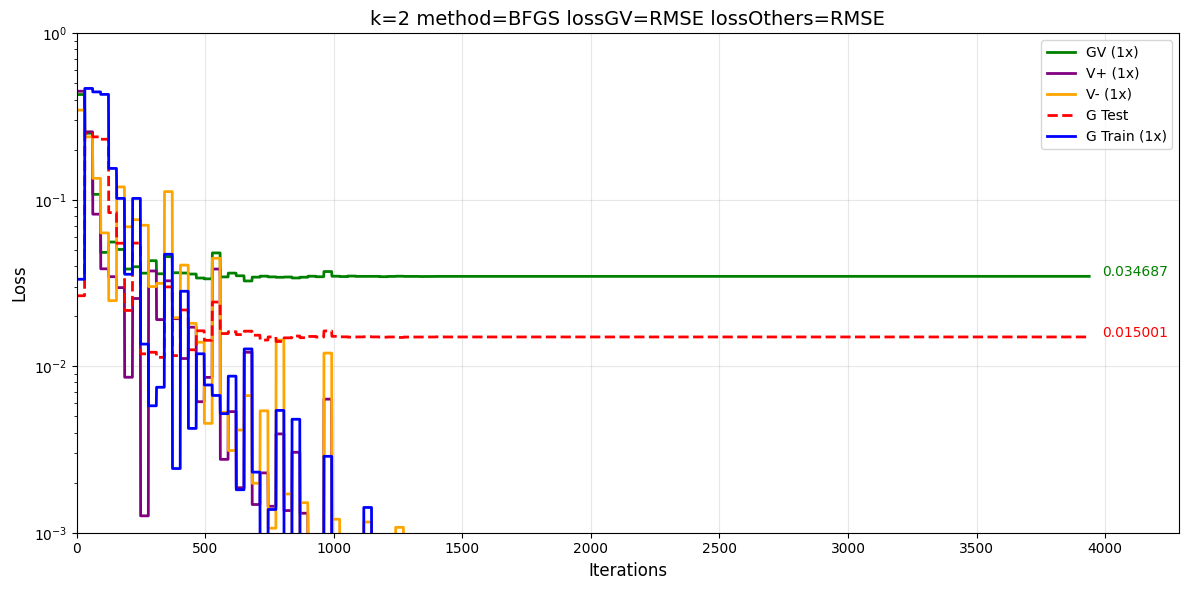

In [71]:

plot_loss(k=2, method='BFGS', lossGV='RMSE', lossOthers='RMSE', weights=[1, 1, 1, 1])

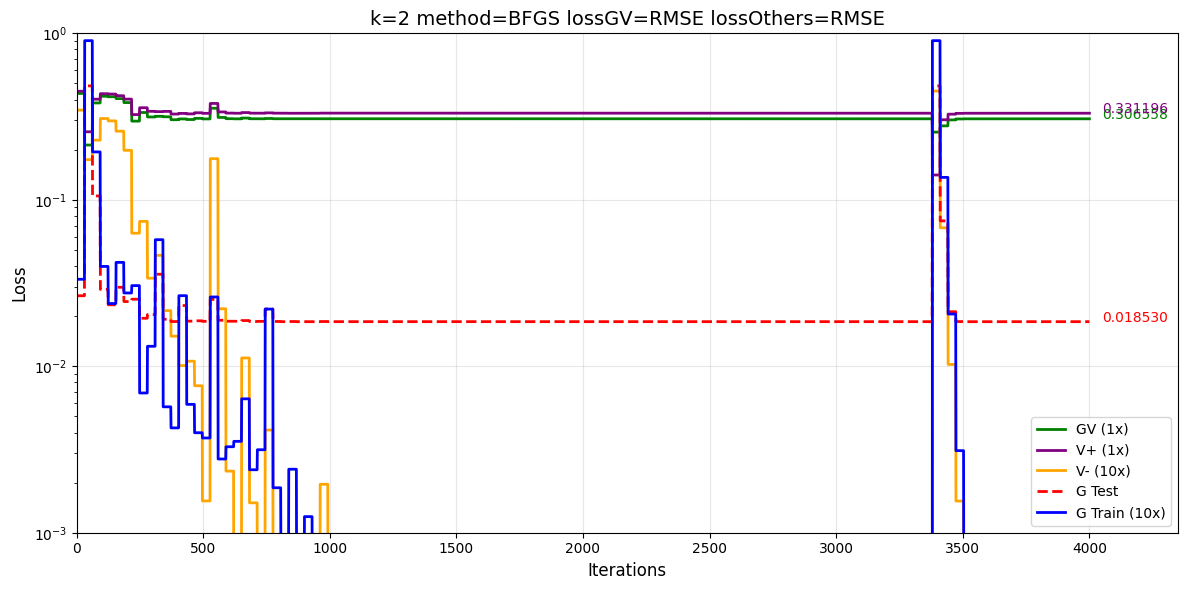

In [73]:

plot_loss(k=2, method='BFGS', lossGV='RMSE', lossOthers='RMSE', weights=[1, 10, 1, 10])

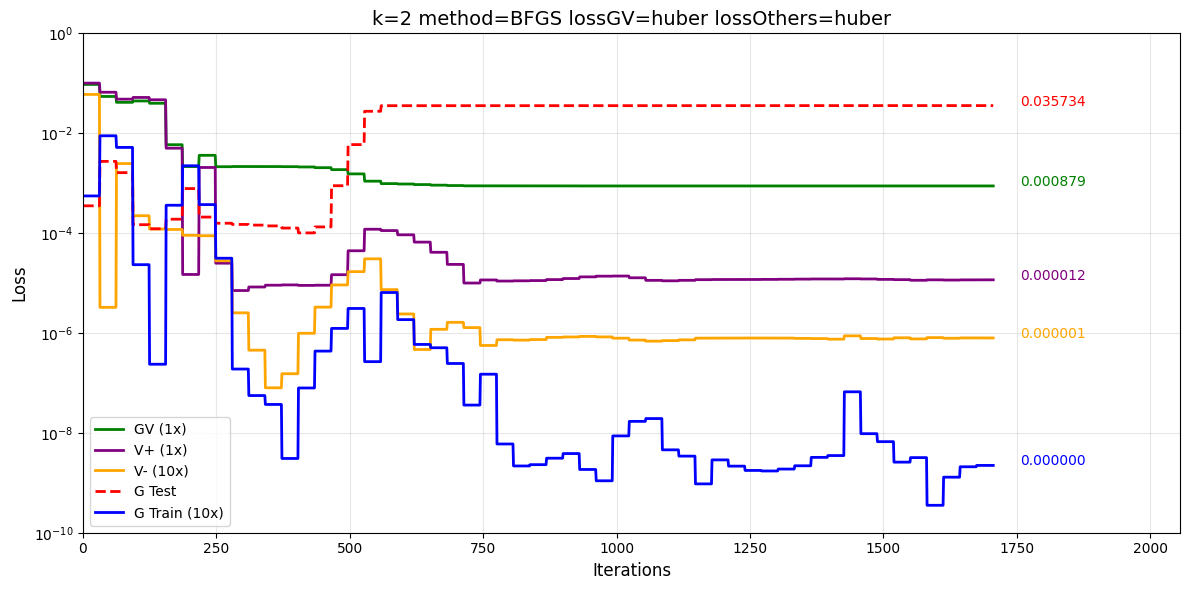

In [78]:
plot_loss(k=2, method='BFGS', lossGV='huber', lossOthers='huber', weights=[1, 10, 1, 10], ylim=1e-10)

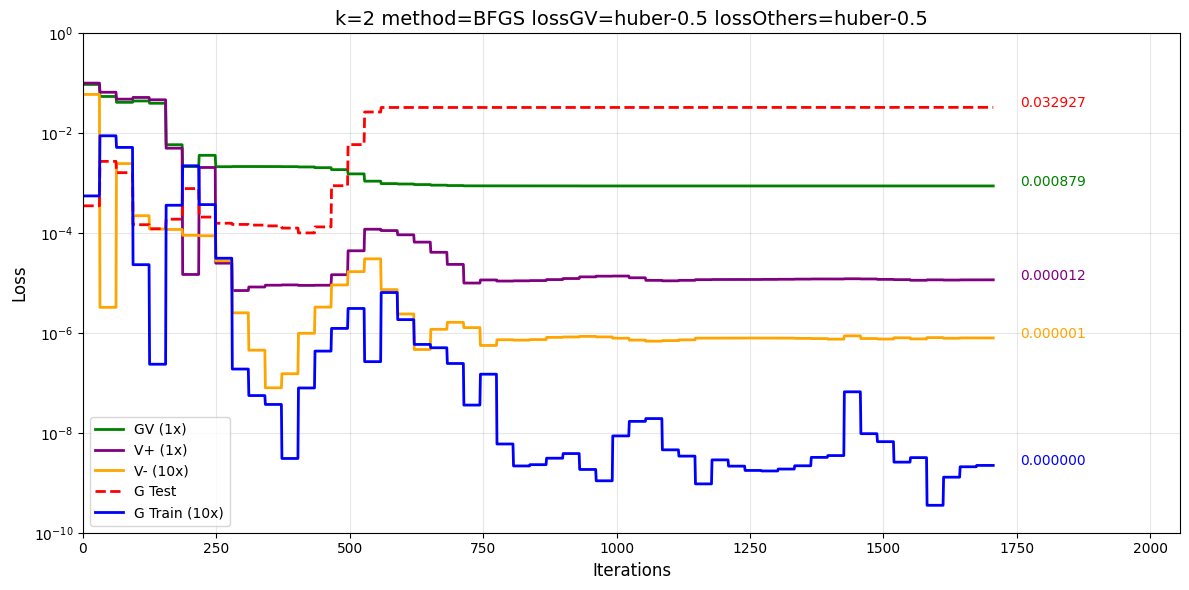

In [80]:
plot_loss(k=2, method='BFGS', lossGV='huber-0.5', lossOthers='huber-0.5', weights=[1, 10, 1, 10], ylim=1e-10)

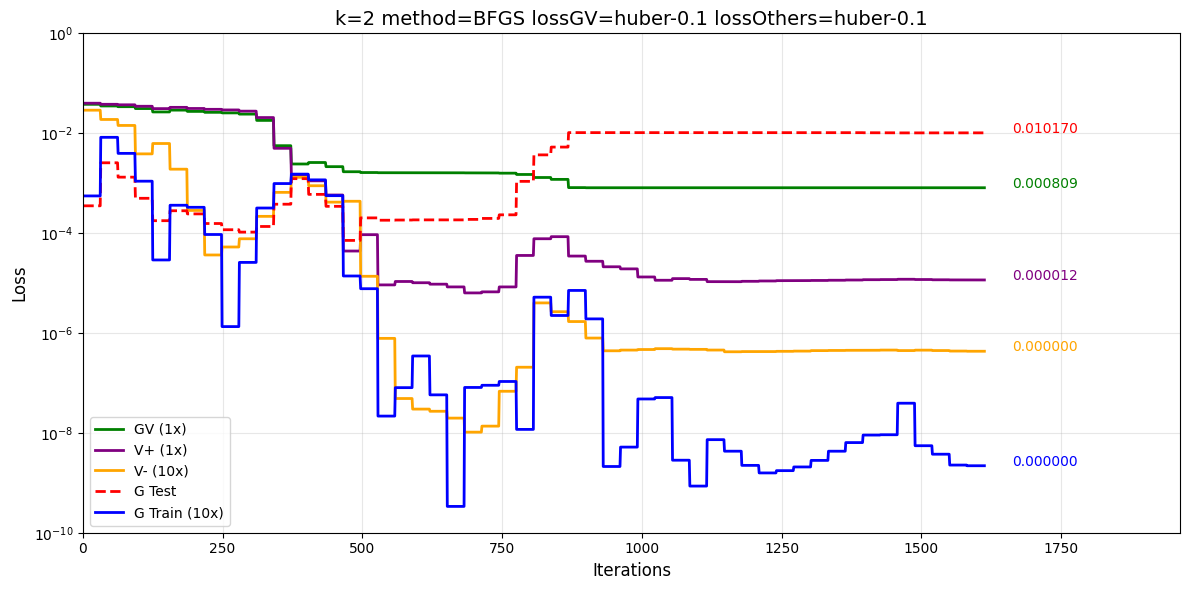

In [81]:
plot_loss(k=2, method='BFGS', lossGV='huber-0.1', lossOthers='huber-0.1', weights=[1, 10, 1, 10], ylim=1e-10)

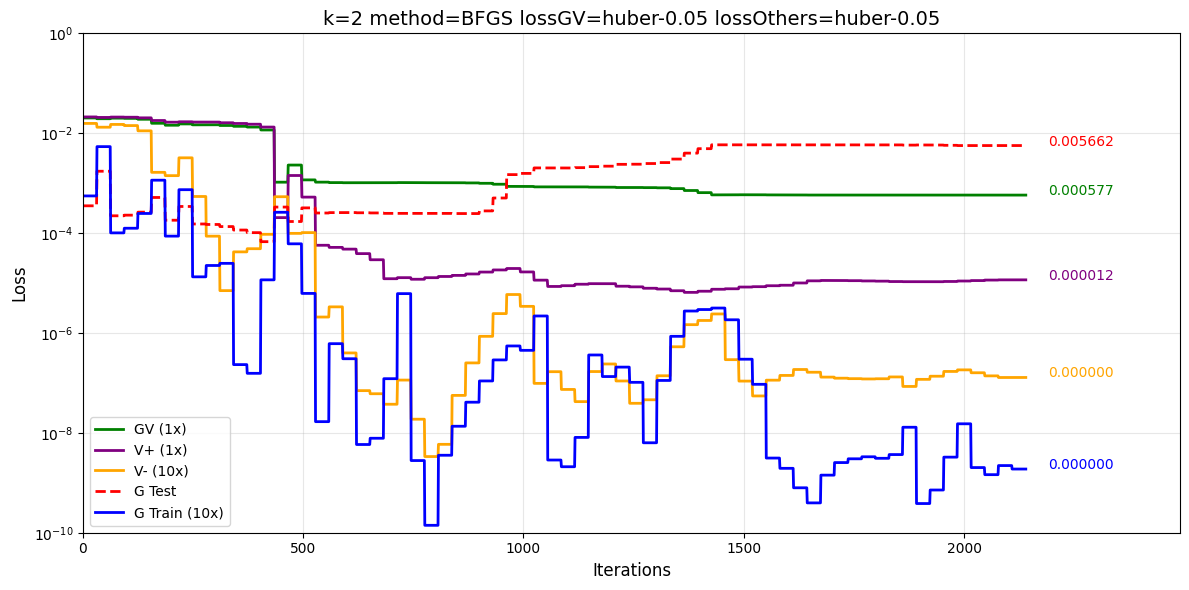

In [82]:
plot_loss(k=2, method='BFGS', lossGV='huber-0.05', lossOthers='huber-0.05', weights=[1, 10, 1, 10], ylim=1e-10)